Loaded pretrained model Qwen2-0.5B into HookedTransformer
Clean Baseline Logit Diff: 2.0107

Running Head-Level Patching...
Layer 17, Head 7 -> Damage: 103.00%
Layer 17, Head 11 -> Damage: 19.40%
Layer 17, Head 13 -> Damage: 33.91%
Layer 20, Head 2 -> Damage: 12.97%
Layer 23, Head 1 -> Damage: 14.45%
Layer 23, Head 4 -> Damage: 10.13%
Layer 23, Head 6 -> Damage: 12.47%

Sweep Complete.

Full Damage Matrix (for target layers):
              H0      H1      H2      H3      H4      H5      H6      H7  \
Layer 10 -0.0002 -0.0047 -0.0084  0.0015  0.0106 -0.0041  0.0000  0.0153   
Layer 13  0.0036  0.0061  0.0079 -0.0084  0.0077 -0.0020 -0.0015 -0.0070   
Layer 17  0.0122  0.0148 -0.0076  0.0116 -0.0114 -0.0061  0.0132  1.0300   
Layer 20 -0.0018  0.0004  0.1297 -0.0033 -0.0040 -0.0163  0.0027 -0.0180   
Layer 23 -0.0267  0.1445 -0.0554 -0.0000  0.1013 -0.0648  0.1247 -0.0178   

              H8      H9     H10     H11     H12     H13  
Layer 10 -0.0053  0.0005 -0.0000  0.0007  0.0072 -0.00

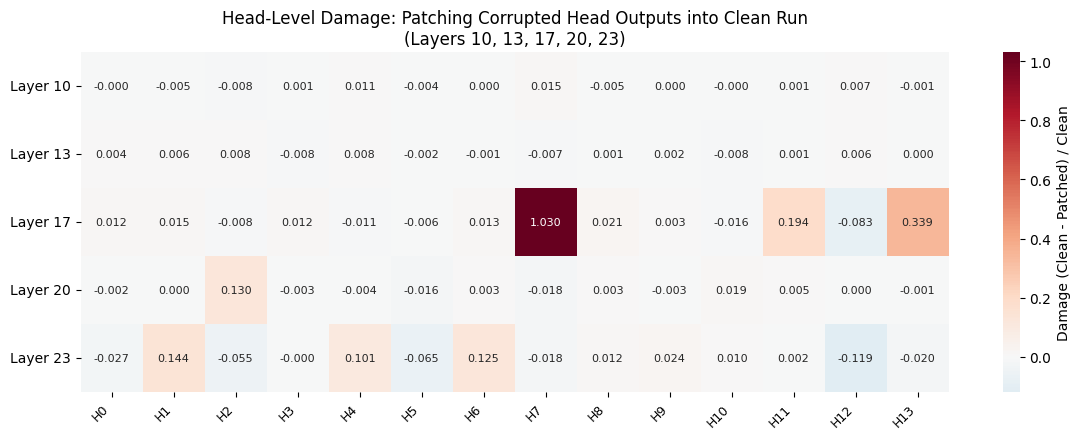

In [3]:
import torch
from transformer_lens import HookedTransformer
from functools import partial
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model = HookedTransformer.from_pretrained(
    "Qwen2-0.5B", 
    fold_ln=False, 
    center_writing_weights=False, 
    device="cuda" if torch.cuda.is_available() else "cpu"
)

clean_prompt = "I am using the Euro, so I am in"
corrupted_prompt = "I am using the Yen, so I am in"

clean_target_token = model.to_single_token(" Europe") 
corrupted_target_token = model.to_single_token(" Japan")

corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_prompt)

def get_logit_diff(logits, clean_tok, corrupted_tok):
    final_token_logits = logits[0, -1, :]
    return final_token_logits[clean_tok] - final_token_logits[corrupted_tok]

clean_logits = model(clean_prompt)
clean_baseline = get_logit_diff(clean_logits, clean_target_token, corrupted_target_token).item()

def head_patch_hook(z, hook, head_idx, cache):
    z[0, -1, head_idx, :] = cache[hook.name][0, -1, head_idx, :]
    return z

target_layers = [10, 13, 17, 20, 23] 
n_heads = model.cfg.n_heads

head_results = torch.zeros(model.cfg.n_layers, n_heads)

print(f"Clean Baseline Logit Diff: {clean_baseline:.4f}\n")
print("Running Head-Level Patching...")

for layer in target_layers:
    for head in range(n_heads):
        hook_name = f"blocks.{layer}.attn.hook_z"
        
        hook_fn = partial(head_patch_hook, head_idx=head, cache=corrupted_cache)
        
        patched_logits = model.run_with_hooks(
            clean_prompt,
            fwd_hooks=[(hook_name, hook_fn)]
        )
        
        patched_diff = get_logit_diff(patched_logits, clean_target_token, corrupted_target_token).item()
        
        damage = (clean_baseline - patched_diff) / clean_baseline
        head_results[layer, head] = damage
        
        if damage > 0.10:
            print(f"Layer {layer}, Head {head} -> Damage: {damage:.2%}")

print("\nSweep Complete.")


df_damage = pd.DataFrame(
    head_results[target_layers].numpy(),
    index=[f"Layer {l}" for l in target_layers],
    columns=[f"H{h}" for h in range(n_heads)]  # shorter column labels
)
print("\nFull Damage Matrix (for target layers):")
print(df_damage.round(4))

df_damage.to_csv("head_damage_matrix.csv")
print("\nDamage matrix saved to 'head_damage_matrix.csv'")

print("\n--- Summary per layer (mean damage across heads) ---")
for layer in target_layers:
    mean_damage = head_results[layer].mean().item()
    print(f"Layer {layer}: mean damage = {mean_damage:.4f}")


plt.figure(figsize=(14, 5))  
ax = sns.heatmap(
    df_damage,
    annot=True,
    fmt=".3f",
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "Damage (Clean - Patched) / Clean"},
    square=False,            
    annot_kws={"size": 8}   
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.title("Head-Level Damage: Patching Corrupted Head Outputs into Clean Run\n(Layers 10, 13, 17, 20, 23)", fontsize=12)

plt.subplots_adjust(bottom=0.2)

plt.savefig("head_damage_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()